Explore region behavior around sleep oscillating events

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
#import regions as rg
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _regionPETH(session,regs=None,when=None,lim_oscill=None,n_bins=None,lim_isa=None):

    # load data
    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval',phases=when)
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')
    events, is_coupled = isru.loadHpcPfcEvents(session,coupl=True,delta='ripples')
    #off_on, on_off = isru.ISTransitions(isa,R.eventIntervals('slowavalnr'),[0.5,0.5])

    # determine isa
    is_isa = {e: fma.general.restrict(events[e],isa,s_ind=True)[1] for e in events}

    fr = R.firingRate(regs=regs,window=0.010,step=3,norm=True)
    peth = {}
    for name in events:
        p, t, _ = fma.analysis.PETH(fr,events[name],limits=lim_oscill,n_bins=n_bins) # (events, time, regions)
        peth[name] = xr.DataArray(p,dims=['event','t','reg'],coords={'isa': ('event', is_isa[name]),'coupl': ('event', is_coupled[name]),'t': t, 'reg': regs, 'rat': int(R.rat)})

    # peth_isa = {}
    # p, t, _ = fma.analysis.PETH(fr,off_on,limits=lim_isa)
    # peth_isa['off_on'] = xr.DataArray(p,dims=['event','t','reg'],coords={'t': t, 'reg': regs, 'rat': int(R.rat)})
    # p, t, _ = fma.analysis.PETH(fr,on_off,limits=lim_isa)
    # peth_isa['on_off'] = xr.DataArray(p,dims=['event','t','reg'],coords={'t': t, 'reg': regs, 'rat': int(R.rat)})

    # peth_oscill = []
    # for name in names:
    #     peth_oscill.append([])
    #     _, t, p = fma.analysis.PETH(events[name],off_on,limits=lim_isa,n_bins=41,fast=True) # (time,)
    #     peth_oscill[-1].append(p)
    #     _, t, p = fma.analysis.PETH(events[name],on_off,limits=lim_isa,n_bins=41,fast=True) # (time,)
    #     peth_oscill[-1].append(p)
    # peth_oscill = xr.DataArray(peth_oscill,dims=['name','tran','t'],coords={'name': names, 'tran': ['off_on','on_off'], 't': t, 'rat': int(R.rat)})

    return peth, events #, peth_isa, peth_oscill

In [3]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][10]
print(session)
peth, events = _regionPETH(session,lim_oscill=[-0.3,0.3],n_bins=201)

/mnt/hubel-data-139/perceval/Rat003_20231226/Rat003_20231226.xml


KeyboardInterrupt: 

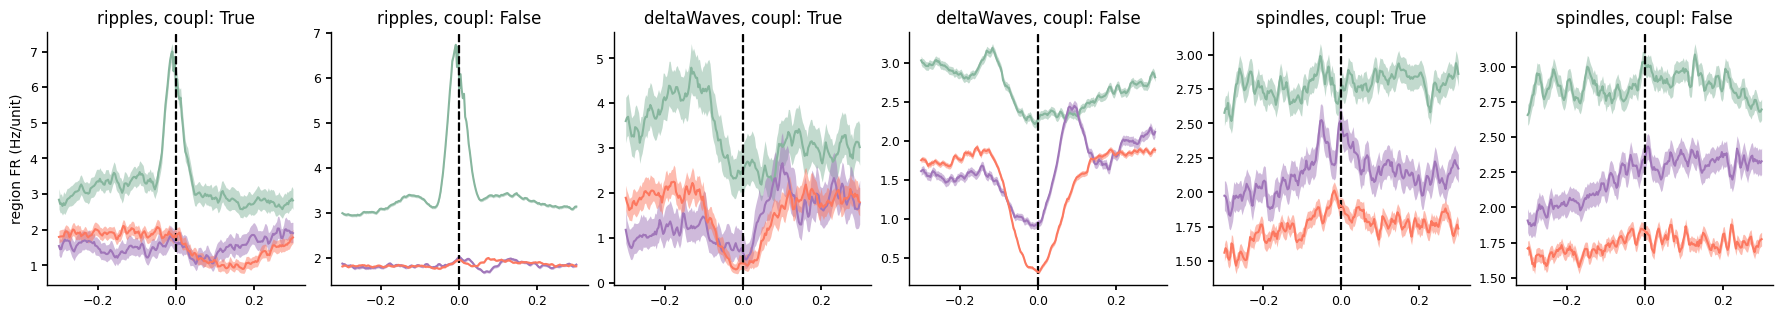

In [6]:
# see activity irrespective of ISA
fig, ax = fma.plotting.makeFigure(n=[1,len(peth)*2],size=[45,8])
for i, (name, fr_p) in enumerate(peth.items()):
        for coupl in [True,False]:
            for r in fr_p['reg'].values:
                ax[2*i+(not coupl)].set_title(f'{name}, coupl: {coupl}')
                ax[2*i+(not coupl)].axvline(0,color='k',ls='--')
                fma.plotting.semPlot(fr_p['t'],fr_p.where(fr_p.coupl==coupl, drop=True).sel(reg=r),color=isru.paperColors(r),ax=ax[2*i+(not coupl)])
ax[0].set(ylabel='region FR (Hz/unit)');

Q: a cosa serve il picco NR all'UP state?

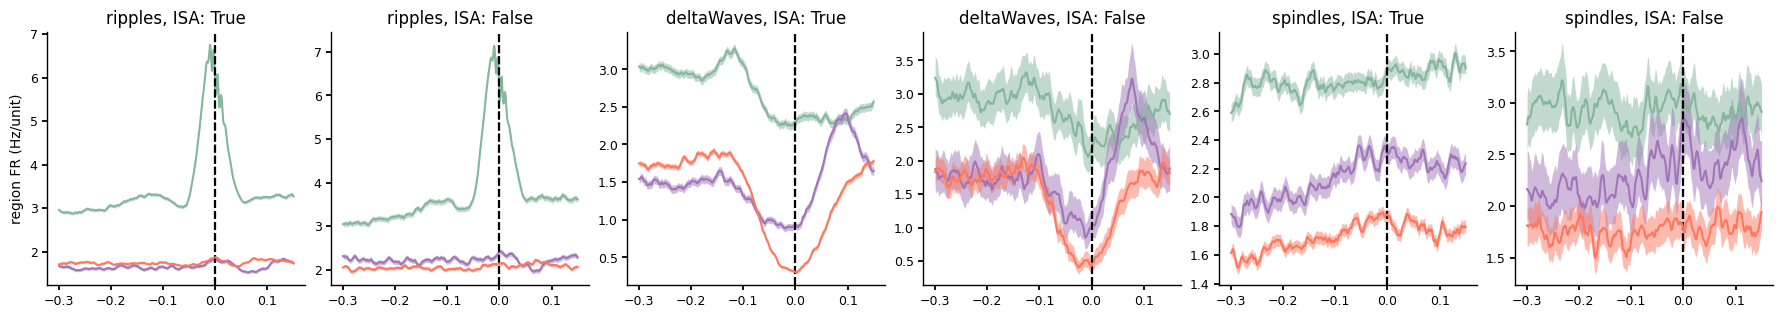

In [5]:
# see activity irrespective of coupling
fig, ax = fma.plotting.makeFigure(n=[1,len(peth)*2],size=[45,8])
for i, (name, fr_p) in enumerate(peth.items()):
        for isa in [True,False]:
            for r in fr_p['reg'].values:
                ax[2*i+(not isa)].set_title(f'{name}, ISA: {isa}')
                ax[2*i+(not isa)].axvline(0,color='k',ls='--')
                fma.plotting.semPlot(fr_p['t'],fr_p.where(fr_p.isa==isa, drop=True).sel(reg=r),color=isru.paperColors(r),ax=ax[2*i+(not isa)])
ax[0].set(ylabel='region FR (Hz/unit)');

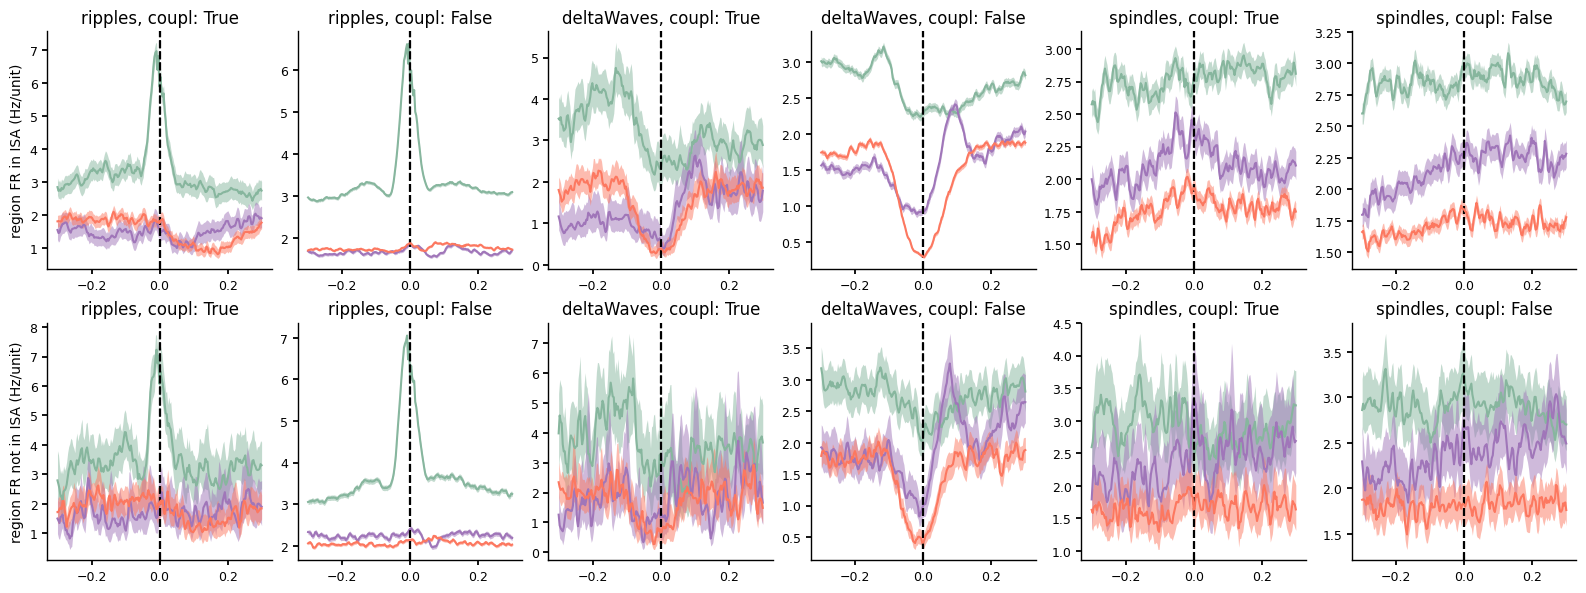

In [37]:
fig, ax = fma.plotting.makeFigure(n=[2,len(peth)*2],size=[40,15])
for i, (name, fr_p) in enumerate(peth.items()):
    for isa in [True,False]:
        for coupl in [True,False]:
            for r in fr_p['reg'].values:
                ax[int(not isa),2*i+(not coupl)].set_title(f'{name}, coupl: {coupl}')
                ax[int(not isa),2*i+(not coupl)].axvline(0,color='k',ls='--')
                fma.plotting.semPlot(fr_p['t'],fr_p.where((fr_p.isa==isa) & (fr_p.coupl==coupl), drop=True).sel(reg=r),color=isru.paperColors(r),ax=ax[int(not isa),2*i+(not coupl)])
ax[0,0].set(ylabel='region FR in ISA (Hz/unit)'); ax[1,0].set(ylabel='region FR not in ISA (Hz/unit)');

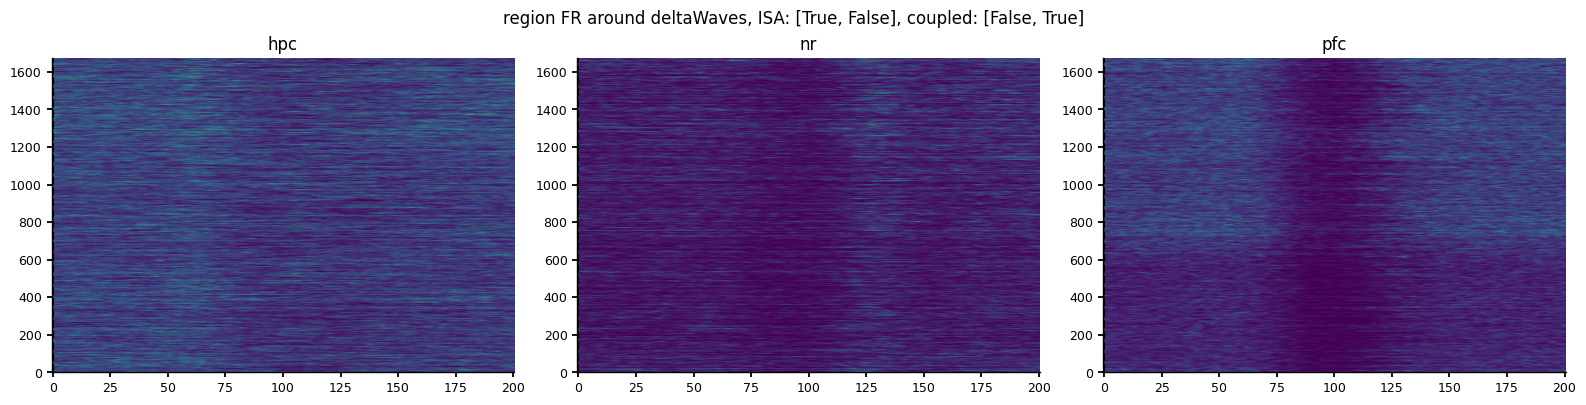

In [36]:
# see ripple activity PETH
name = 'deltaWaves'
isa = [True,False]
coupl = [False,True]
valid = xr.DataArray((np.isin(peth[name].isa,isa)) & (np.isin(peth[name].coupl,coupl)),dims='event')
fr_p = peth[name].where(valid,drop=True)
fig, ax = fma.plotting.makeFigure(f'region FR around {name}, ISA: {isa}, coupled: {coupl}',n=[1,len(fr_p['reg'])],size=[40,10])

for i, r in enumerate(fr_p['reg'].values):
    ax[i].set_title(r)
    ax[i].axvline(0,color='k',ls='--')
    fma.plotting.plotColorMap(fr_p.sel(reg=r).values,sortby=None,ax=ax[i],zscore=None)

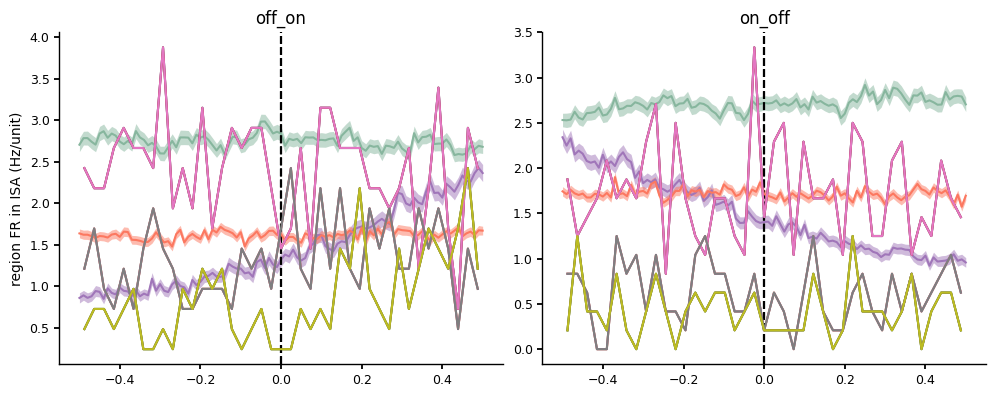

In [39]:
fig, ax = fma.plotting.makeFigure(n=[1,len(peth_isa)],size=[25,10])
for i, (name, fr_p) in enumerate(peth_isa.items()):
    for r in fr_p['reg'].values:
        ax[i].set_title(name)
        ax[i].axvline(0,color='k',ls='--')
        fma.plotting.semPlot(fr_p['t'],fr_p.sel(reg=r),color=isru.paperColors(r),ax=ax[i])
        ax[i].plot(peth_oscill['t'],peth_oscill.sel(tran=name).T*150)
ax[0].set(ylabel='region FR in ISA (Hz/unit)');

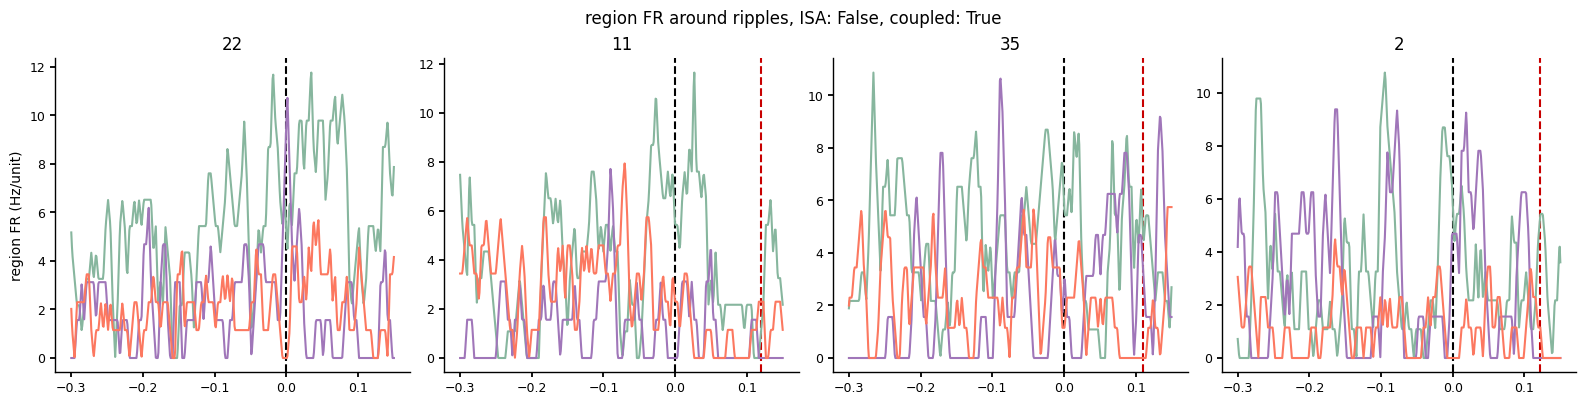

In [70]:
# see example ripples
name = 'ripples'
isa = False
coupl = True
valid = (peth[name].isa==isa) & (peth[name].coupl==coupl)
fig, ax = fma.plotting.makeFigure(f'region FR around {name}, ISA: {isa}, coupled: {coupl}',n=[1,4],size=[40,10])
fr_p = peth[name].where(valid,drop=True)
for j, k in enumerate(np.random.randint(len(fr_p),size=4)):
    ax[j].set_title(k)
    ax[j].axvline(0,color='k',ls='--')
    delt = fma.general.restrict(events['deltaWaves']-events[name][valid][k],fr_p['t'][[0,-1]]).ravel()
    [ax[j].axvline(d,color=isru.paperColors('deltaWaves'),ls='--') for d in delt]
    for r in ['hpc','nr','pfc']:
        ax[j].plot(fr_p['t'],fr_p.sel(reg=r)[k],color=isru.paperColors(r))
ax[0].set(ylabel='region FR (Hz/unit)');

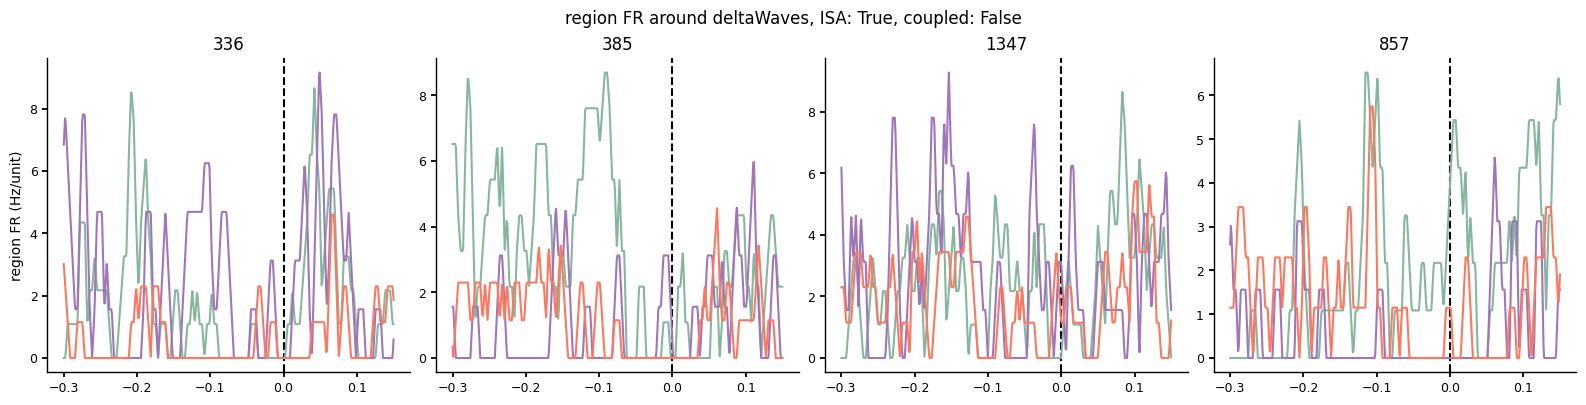

In [73]:
# see example deltas
name = 'deltaWaves'
isa = True
coupl = False
valid = (peth[name].isa==isa) & (peth[name].coupl==coupl)
fig, ax = fma.plotting.makeFigure(f'region FR around {name}, ISA: {isa}, coupled: {coupl}',n=[1,4],size=[40,10])
fr_p = peth[name].where(valid,drop=True)
for j, k in enumerate(np.random.randint(len(fr_p),size=4)):
    ax[j].set_title(k)
    ax[j].axvline(0,color='k',ls='--')
    delt = fma.general.restrict(events['ripples']-events[name][valid][k],fr_p['t'][[0,-1]]).ravel()
    [ax[j].axvline(d,color=isru.paperColors('ripples'),ls='--') for d in delt]
    for r in ['hpc','nr','pfc']:
        ax[j].plot(fr_p['t'],fr_p.sel(reg=r)[k],color=isru.paperColors(r))
ax[0].set(ylabel='region FR (Hz/unit)');